In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("iamsouravbanerjee/animal-image-dataset-90-different-animals")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/animal-image-dataset-90-different-animals


In [ ]:
# Importing necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

In [ ]:
# Ensuring the GPU is being used
physical_devices = tf.config.experimental.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print('GPU is being used.')
else:
    print('GPU is not being used.')

GPU is being used.


In [19]:
# Path to the dataset
import kagglehub

# Download latest version
# Instead of providing dataset path in "owner/dataset-name" format,
#  provide path in the format "owner/dataset-name/version" as the function expects it this way
# Assuming the latest version is 1
path = kagglehub.dataset_download("iamsouravbanerjee/animal-image-dataset-90-different-animals")

print("Path to dataset files:", path)
# List all the classes (Animal Types)
classes = os.listdir(path)
num_classes = len(classes)

# Display the number of classes along with names
print(f'Number of Classes: {num_classes}')
print(f'Classes: {classes}')

Path to dataset files: /kaggle/input/animal-image-dataset-90-different-animals
Number of Classes: 2
Classes: ['animals', 'name of the animals.txt']


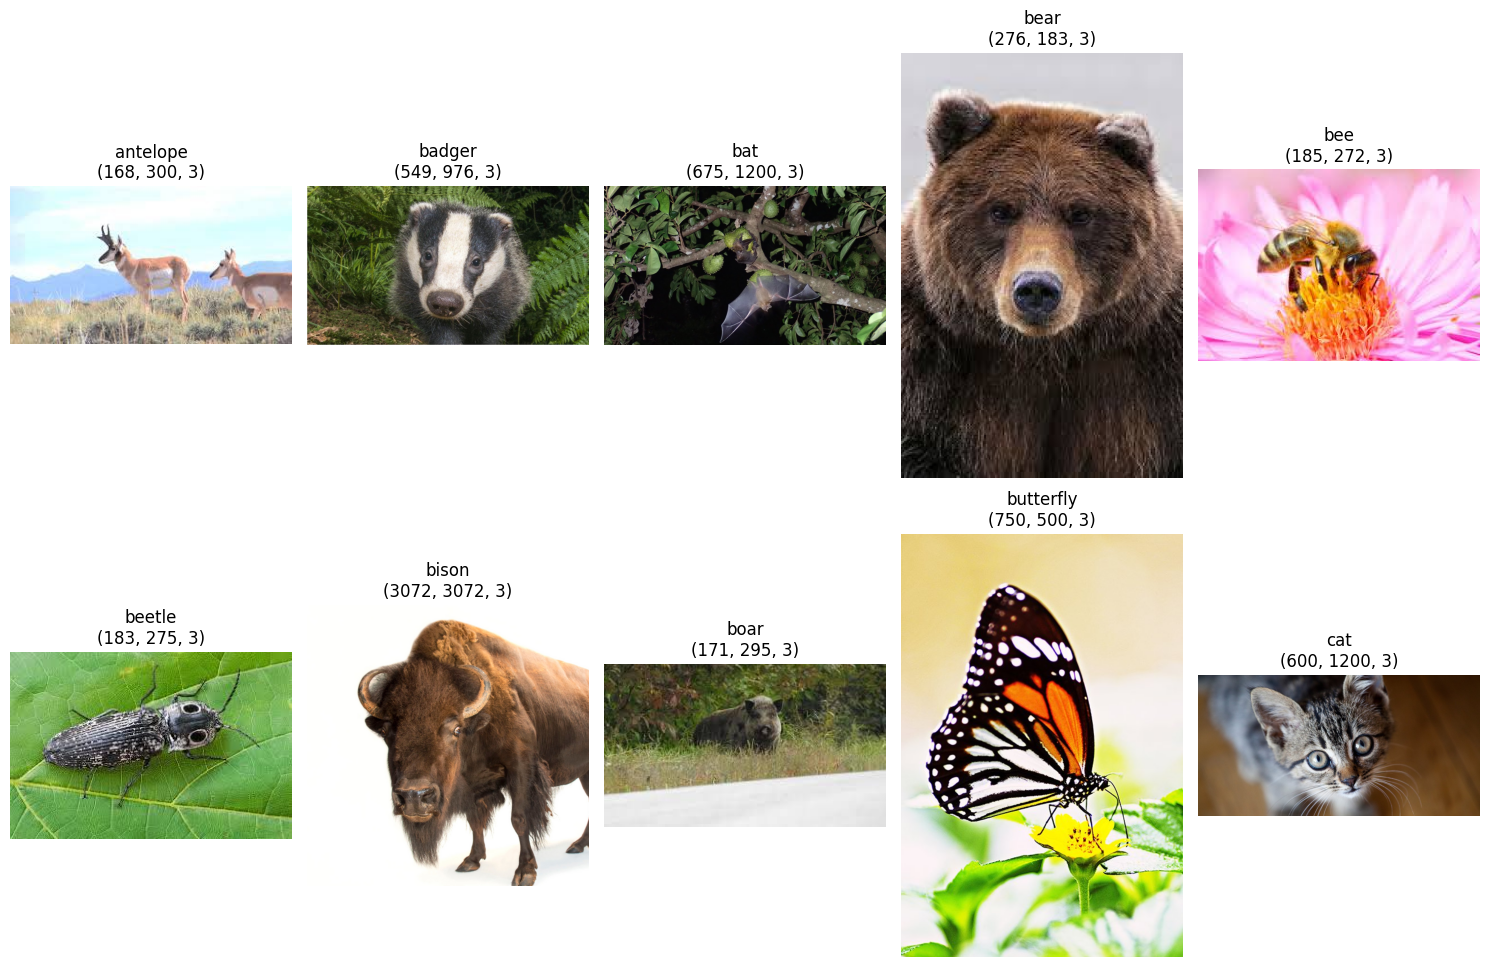

In [28]:
import os
import matplotlib.pyplot as plt

# Actual root path to folders like 'antelope', 'bear', etc.
dataset_path = '/kaggle/input/animal-image-dataset-90-different-animals/animals/animals'

# Read class names from the text file
txt_file_path = '/kaggle/input/animal-image-dataset-90-different-animals/name of the animals.txt'
with open(txt_file_path, 'r') as file:
    class_names = [line.strip().lower() for line in file.readlines()]

# Get actual folder names
available_folders = os.listdir(dataset_path)
available_folders = [f for f in available_folders if os.path.isdir(os.path.join(dataset_path, f))]

# Create mapping from class name to folder name (exact match should work now)
class_folder_map = {name: name for name in class_names if name in available_folders}

# Visualize 10 sample images
plt.figure(figsize=(15, 10))
shown = 0

for class_name in class_names:
    if class_name not in class_folder_map:
        print(f"⚠️ Skipping {class_name} — folder not found in dataset")
        continue

    class_folder = class_folder_map[class_name]
    class_path = os.path.join(dataset_path, class_folder)

    img_files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]
    if not img_files:
        print(f"⚠️ No images in folder: {class_folder}")
        continue

    img_path = os.path.join(class_path, img_files[0])
    img = plt.imread(img_path)

    plt.subplot(2, 5, shown + 1)
    plt.imshow(img)
    plt.title(f'{class_name}\n{img.shape}')
    plt.axis('off')

    shown += 1
    if shown == 10:
        break

plt.tight_layout()
plt.show()
